In [1]:
from IPython.display import display, HTML
try:
    from notebook.services.config import ConfigManager
    cm = ConfigManager()
    cm.update('livereveal', {
        'theme': 'simple',
        'transition': 'fade',
        'start_slideshow_at': 'selected',
    })
except Exception:
    pass
display(HTML('<style>.rise-enabled .cell { font-size: 90%; }</style>'))

# Week 10: Monday, AST 5011: Astrophysical Systems

## The Galaxy-Halo Connection & Gas Accretion

### Michael Coughlin

Reference: Cimatti, Fraternali & Nipoti, Ch. 5-6

With material from Benedikt Diemer (UMD) and Frank van den Bosch (Yale).

In [2]:
import numpy as np
import scipy.integrate
import scipy.optimize
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

from colossus.utils import constants
from colossus.cosmology import cosmology
from colossus.lss import mass_function
from colossus.lss import bias
from colossus.lss import peaks
from colossus.halo import mass_so

import routines
import routines as rt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

cosmo = routines.cosmo
h = cosmo.h
Om0 = cosmo.Om0
Ob0 = cosmo.Ob0
baryon_frac = Ob0 / Om0

---

## The Stellar Mass Function

The stellar mass function (SMF) describes the number density of galaxies as a function of their stellar mass. It is well fit by a Schechter function:

$$\phi(M) \, d\ln M = \phi^* \left(\frac{M}{M^*}\right)^{\alpha+1} \exp\left(-\frac{M}{M^*}\right) d\ln M$$

where:
- $\phi^*$ is the normalization (number density at the "knee")
- $M^*$ is the characteristic mass where the exponential cutoff begins
- $\alpha$ is the faint-end slope ($\alpha < -1$ means many more faint galaxies than bright ones)

We use the fit from Li & White (2009) based on SDSS data:
$M^* = 10^{10.525}\,M_\odot$, $\alpha = -1.155$, $\phi^* = 0.0083\,h^3\,{\rm Mpc}^{-3}$

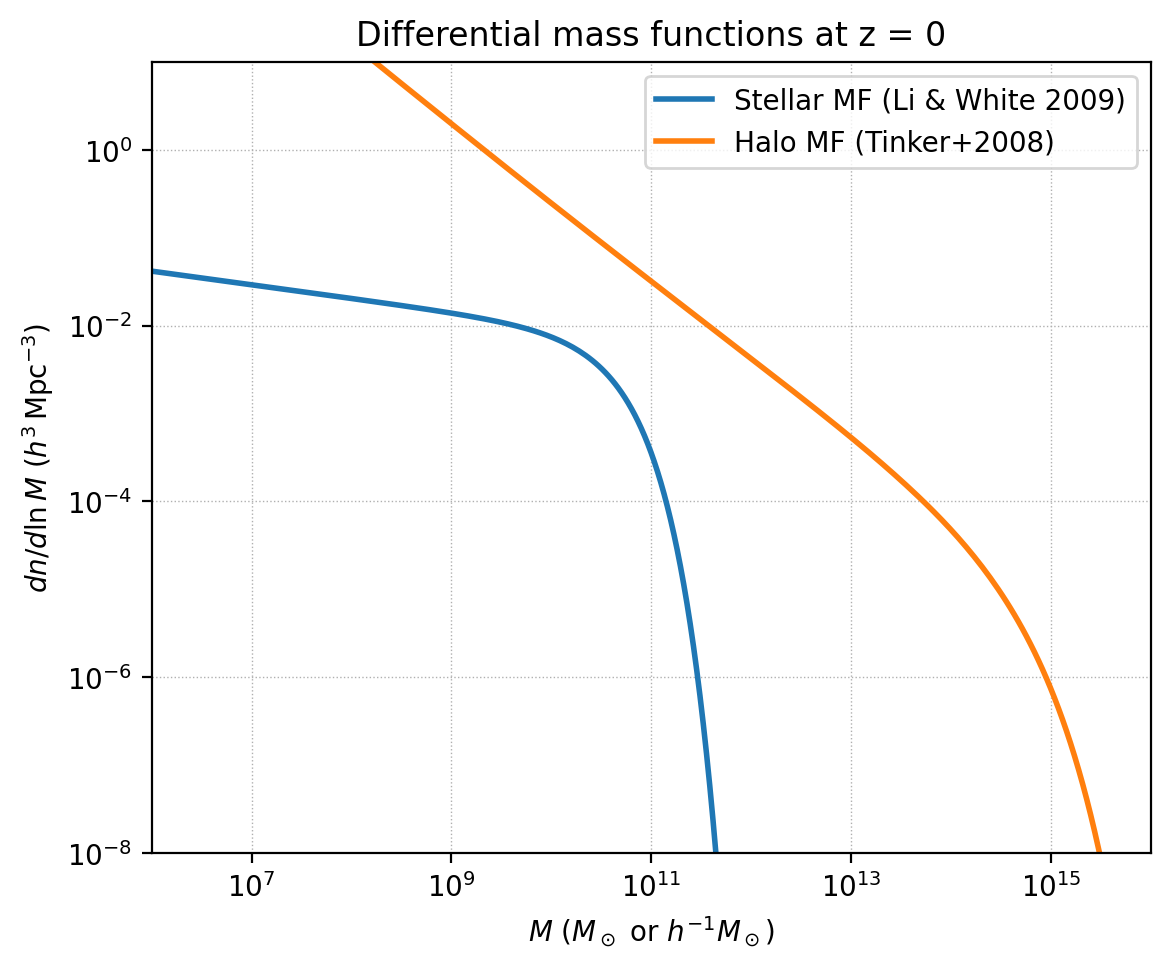

In [3]:
# Stellar mass function parameters (Li & White 2009)
h = cosmo.h
M_knee_star = 10**10.525   # Msun (Li & White h-unit convention)
alpha_star = -1.155
phi_star = 0.0083                   # h^3 Mpc^-3

# Mass arrays
M_star_arr = 10**np.linspace(6.0, 12.5, 200)  # Msun/h
M_halo_arr = 10**np.linspace(8.0, 16.0, 200)  # h^-1 Msun

# Compute mass functions
phi_star_arr = routines.schechterFunctionMass(M_star_arr, phi_star, M_knee_star, alpha_star)
phi_halo_arr = mass_function.massFunction(M_halo_arr, 0.0, q_in='M', q_out='dndlnM',
                                           model='tinker08', mdef='200m')

plt.figure(figsize=(6, 5))
plt.loglog()
plt.xlabel(r'$M\ (M_\odot\ {\rm or}\ h^{-1} M_\odot)$')
plt.ylabel(r'$dn / d\ln M\ (h^3\, {\rm Mpc}^{-3})$')
plt.xlim(1e6, 1e16)
plt.ylim(1e-8, 1e1)
plt.grid(lw=0.5, ls=':')

plt.plot(M_star_arr, phi_star_arr, '-', lw=2, label='Stellar MF (Li & White 2009)')
plt.plot(M_halo_arr, phi_halo_arr, '-', lw=2, label='Halo MF (Tinker+2008)')

plt.legend()
plt.title('Differential mass functions at z = 0')
plt.tight_layout()
plt.show()

---

## Abundance Matching

The fundamental idea of abundance matching is simple:

> Rank-order galaxies by stellar mass and halos by halo mass. The most massive galaxy lives in the most massive halo.

Formally, we match at fixed cumulative number density:

$$n(> M_*) = n(> M_{\rm halo})$$

This requires computing the cumulative (integral) mass functions from high mass downward. The matching then gives us a one-to-one mapping $M_*(M_{\rm halo})$ — the stellar-to-halo mass relation (SHMR).

This simple model works remarkably well because both mass functions are monotonically decreasing.

Computing cumulative stellar mass function...
Computing cumulative halo mass function...
Done.


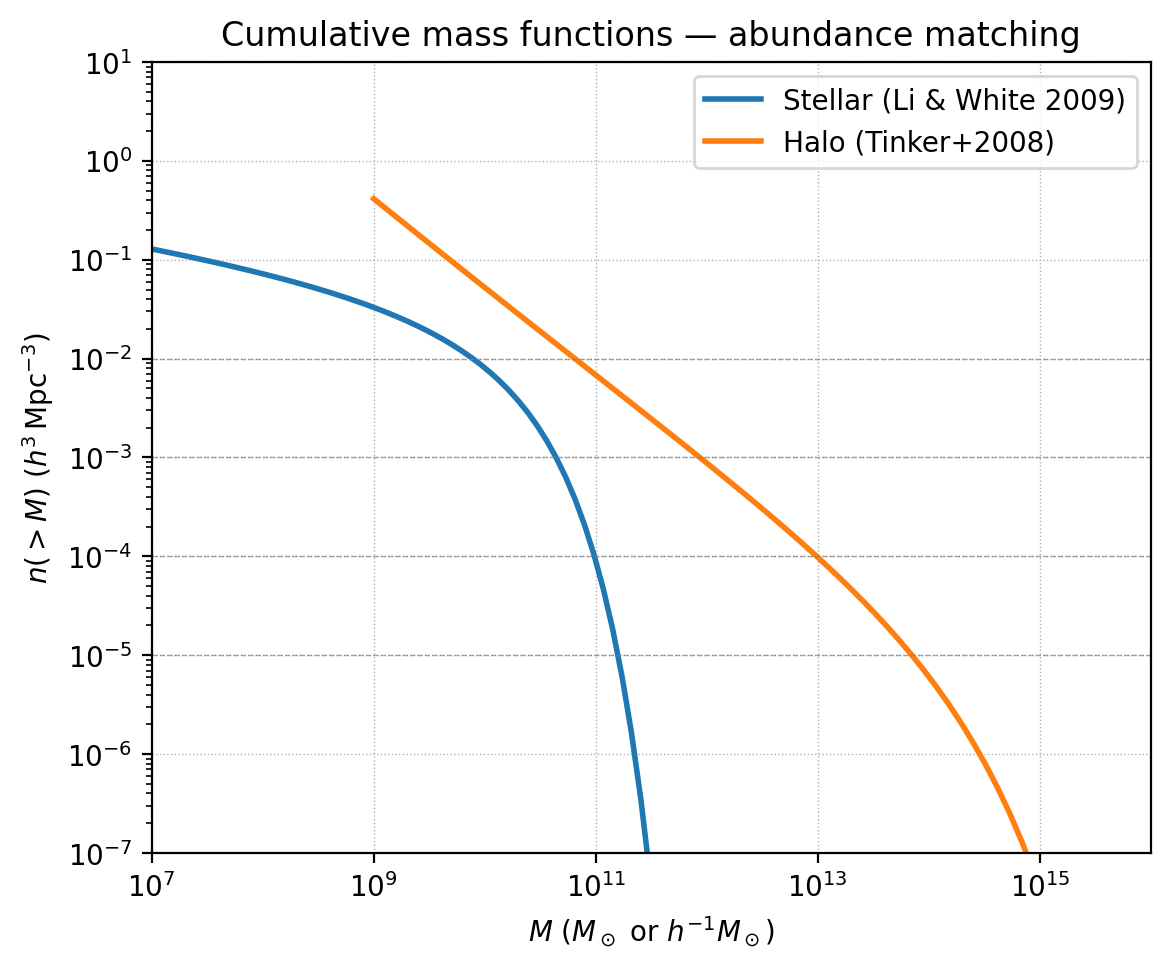

In [4]:
# Compute cumulative mass functions
# This takes ~10s because we integrate numerically at each mass
print('Computing cumulative stellar mass function...')
M_star_cumul = 10**np.linspace(7.0, 12.0, 60)  # Msun/h
n_star_cumul = routines.cumulativeStellarMF(M_star_cumul, phi_star, M_knee_star, alpha_star)

print('Computing cumulative halo mass function...')
M_halo_cumul = 10**np.linspace(9.0, 15.5, 60)  # h^-1 Msun
n_halo_cumul = routines.cumulativeHaloMF(M_halo_cumul, z=0.0)
print('Done.')

# Plot
plt.figure(figsize=(6, 5))
plt.loglog()
plt.xlabel(r'$M\ (M_\odot\ {\rm or}\ h^{-1} M_\odot)$')
plt.ylabel(r'$n(>M)\ (h^3\, {\rm Mpc}^{-3})$')
plt.xlim(1e7, 1e16)
plt.ylim(1e-7, 1e1)
plt.grid(lw=0.5, ls=':')

plt.plot(M_star_cumul, n_star_cumul, '-', lw=2, label='Stellar (Li & White 2009)')
plt.plot(M_halo_cumul, n_halo_cumul, '-', lw=2, label='Halo (Tinker+2008)')

# Draw matching lines at a few densities
for n_match in [1e-2, 1e-3, 1e-4, 1e-5]:
    plt.axhline(n_match, ls='--', color='gray', lw=0.5, alpha=0.7)

plt.legend()
plt.title('Cumulative mass functions — abundance matching')
plt.tight_layout()
plt.show()

---

### Exercise 1: Abundance Matching

In this exercise, you will perform abundance matching to derive the stellar-to-halo mass relation $M_*(M_{\rm halo})$.

Steps:
1. The cumulative mass functions have been pre-computed above.
2. FILL IN: For each halo mass, find the stellar mass at the same cumulative number density using interpolation.
3. Plot the resulting $M_*(M_{\rm halo})$ relation.
4. Compare to the Behroozi et al. (2013) observational constraint.

*Hint:* Use `np.interp()` to interpolate. Since `np.interp` requires monotonically increasing x, you may need to flip the arrays.

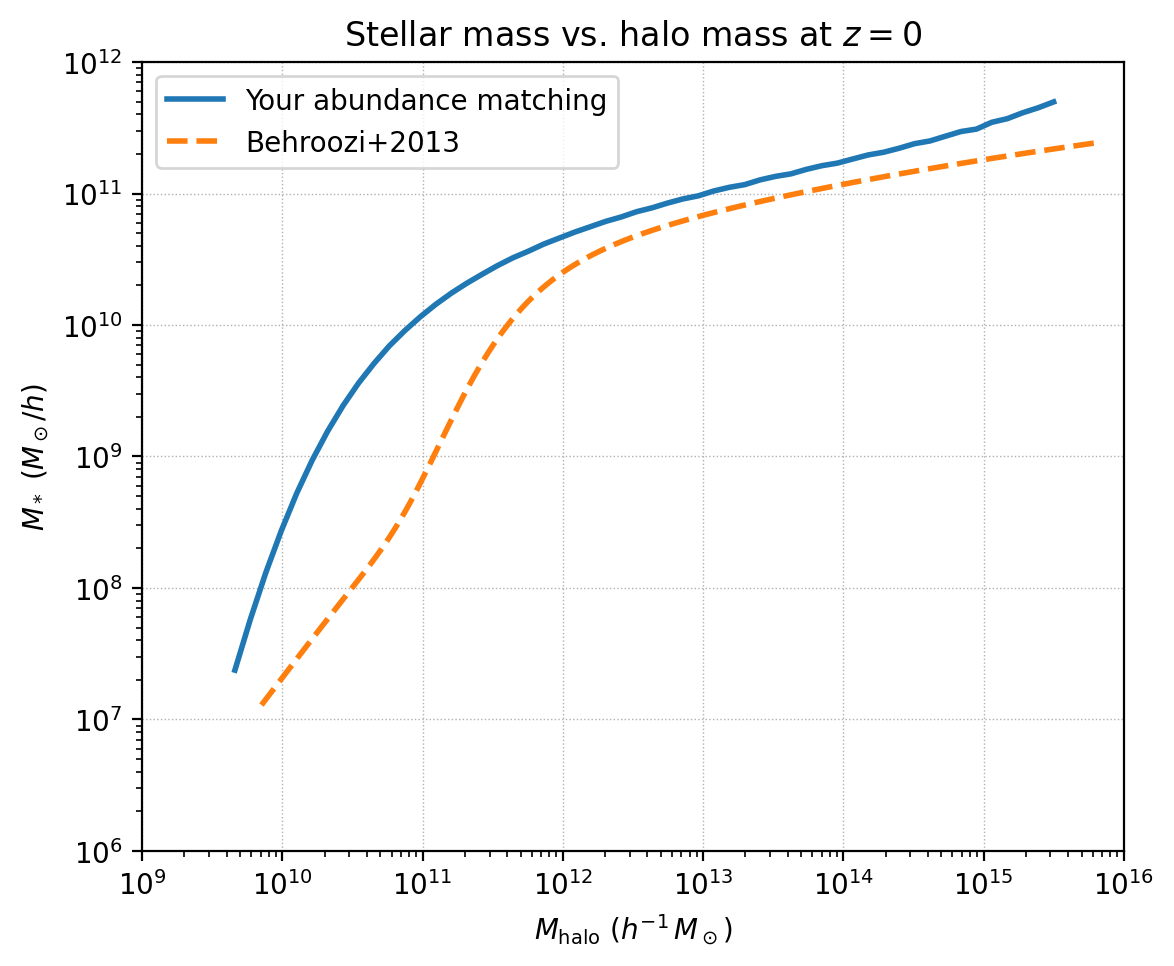

In [5]:
# Exercise 1: Abundance Matching

# We want to find M_star for each M_halo by matching cumulative densities.
# n_star_cumul and n_halo_cumul were computed above.

# Step 1: For each halo mass, get the cumulative number density
# (already computed: n_halo_cumul for M_halo_cumul)

# Step 2: Match to stellar masses at the same number density
# n_star_cumul is a decreasing function of M_star, so we flip for interpolation
M_star_matched = np.interp(n_halo_cumul, n_star_cumul[::-1], M_star_cumul[::-1])

# Step 3: Restrict to the range where both functions overlap
# (avoid extrapolation at very low or high number densities)
n_min = max(n_star_cumul.min(), n_halo_cumul.min())
n_max = min(n_star_cumul.max(), n_halo_cumul.max())
mask = (n_halo_cumul >= n_min) & (n_halo_cumul <= n_max)

# Step 4: Compare to Behroozi+2013
Mvir_beh, ratio_beh = routines.shmrBehroozi13()

# Plot M_star vs M_halo
plt.figure(figsize=(6, 5))
plt.loglog()
plt.xlabel(r'$M_{\rm halo}\ (h^{-1}\, M_\odot)$')
plt.ylabel(r'$M_*\ (M_\odot / h)$')
plt.xlim(1e9, 1e16)
plt.ylim(1e6, 1e12)
plt.grid(lw=0.5, ls=':')

plt.plot(M_halo_cumul[mask], M_star_matched[mask], '-', lw=2, label='Your abundance matching')
plt.plot(Mvir_beh * cosmo.h, ratio_beh * Mvir_beh * cosmo.h, '--', lw=2,
         label='Behroozi+2013')

plt.legend()
plt.title(r'Stellar mass vs. halo mass at $z = 0$')
plt.tight_layout()
plt.show()

### Abundance Matching with Simulated Halos

The analytical approach above uses the Tinker+2008 halo mass function, which counts only distinct (host) halos. But the stellar mass function includes satellite galaxies living in subhalos. To properly match, we should include subhalos in the halo count.

We use halo catalogs from the Erebos N-body simulations, where we track the peak mass $M_{\rm peak}$ — the maximum virial mass a halo ever attained. This is a better proxy for galaxy stellar mass because subhalos lose mass after infall (tidal stripping), but their galaxies largely retain their stars.

In [ ]:
# Abundance matching with simulated halos (including subhalos)
import h5py

sim_name = 'l0063-bol'
fn = routines.nbody_data_dir + 'nbody/tree_%s.hdf5' % sim_name

try:
    f = h5py.File(fn, 'r')
    L_box = f['simulation'].attrs['box_size']
    m_ptl = f['simulation'].attrs['particle_mass']
    mask_alive = np.array(f['mask_alive'][-1, :]).astype(bool)
    Mvir_all = np.array(f['Mvir'])
    f.close()

    # Peak mass: max Mvir over each halo's history (better proxy for galaxy mass)
    Mpeak = np.max(Mvir_all, axis=0)
    M_min_ptl = m_ptl * 200
    mask_sim = (Mpeak >= M_min_ptl) & mask_alive
    Mpeak = Mpeak[mask_sim]
    print('Loaded %d halos (host + sub) from %s' % (len(Mpeak), sim_name))

    # Cumulative mass function from simulation
    mf_hist, bin_edges = np.histogram(np.log10(Mpeak), bins=50)
    sim_bins = 10**bin_edges[:-1]
    sim_cumu = np.cumsum(mf_hist[::-1])[::-1] / L_box**3

    # Abundance match using simulation cumulative MF
    sim_am_mask = (n_star_cumul > sim_cumu.min()) & (n_star_cumul < sim_cumu.max())
    M_star_sim = M_star_cumul[sim_am_mask]
    n_star_sim = n_star_cumul[sim_am_mask]
    M_halo_sim = np.interp(n_star_sim, sim_cumu[::-1], sim_bins[::-1])

    # Plot: compare analytical vs simulation-based SHMR
    Mvir_beh, ratio_beh = routines.shmrBehroozi13()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Left: M_star vs M_halo
    plt.sca(axes[0])
    plt.loglog()
    plt.xlabel(r'$M_{\rm halo}\ (h^{-1}\, M_\odot)$')
    plt.ylabel(r'$M_*\ (M_\odot / h)$')
    plt.xlim(1e9, 1e15)
    plt.ylim(1e6, 1e12)
    plt.grid(lw=0.5, ls=':')

    plt.plot(M_halo_cumul[mask], M_star_matched[mask], '-', lw=2,
             label='AM (Tinker08, host only)')
    plt.plot(M_halo_sim, M_star_sim, '--', lw=2,
             label=r'AM (simulation, host+sub, $M_{\rm peak}$)')
    plt.plot(Mvir_beh * cosmo.h, ratio_beh * Mvir_beh * cosmo.h, ':',
             lw=1.5, color='gray', label='Behroozi+2013')
    plt.legend(fontsize=9)
    plt.title('Effect of including subhalos')

    # Right: SHMR ratio
    plt.sca(axes[1])
    plt.loglog()
    plt.xlabel(r'$M_{\rm halo}\ (M_\odot)$')
    plt.ylabel(r'$M_* / M_{\rm halo}$')
    plt.xlim(1e9, 1e15)
    plt.ylim(1e-5, 0.1)
    plt.grid(lw=0.5, ls=':')

    f_b = cosmo.Ob0 / cosmo.Om0
    plt.axhline(f_b, ls='--', color='gray', lw=0.8, label=r'$f_b$')
    plt.plot(M_halo_cumul[mask] / cosmo.h,
             M_star_matched[mask] / M_halo_cumul[mask] * cosmo.h, '-', lw=2,
             label='AM (Tinker08)')
    plt.plot(M_halo_sim / cosmo.h,
             M_star_sim / M_halo_sim * cosmo.h, '--', lw=2,
             label=r'AM (sim, $M_{\rm peak}$)')
    plt.plot(Mvir_beh, ratio_beh, ':', lw=1.5, color='gray', label='Behroozi+2013')
    plt.legend(fontsize=9)
    plt.title(r'$M_*/M_{\rm halo}$: host-only vs. with subhalos')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print('Erebos simulation data not found. Skipping simulation-based matching.')

---

## The Stellar-to-Halo Mass Relation (SHMR)

The SHMR is often expressed as the ratio $M_*/M_{\rm halo}$, which reveals the star formation efficiency — what fraction of the available baryons have been converted to stars.

Key features:
- The ratio peaks at $M_{\rm halo} \sim 10^{12}\,M_\odot$ (Milky Way-mass halos), where $M_*/M_{\rm halo} \sim 0.03$
- At lower masses, feedback from supernovae and stellar winds suppresses star formation
- At higher masses, AGN feedback heats the gas and shuts down star formation
- No halo converts more than $\sim 20\%$ of its baryons into stars

### Exercise 2: Star Formation Efficiency

In this exercise, you will compute the star formation efficiency as a function of halo mass and compare to observational constraints.

Steps:
1. FILL IN: Compute the ratio $M_*/M_{\rm halo}$ from your abundance matching result
2. FILL IN: Compute the cosmic baryon fraction $f_b = \Omega_b / \Omega_m$
3. FILL IN: Compute the star formation efficiency $\epsilon = (M_*/M_{\rm halo}) / f_b$
4. Compare to the Behroozi+2013 and Kravtsov+2018 observational constraints
5. Find the halo mass where efficiency peaks

Cosmic baryon fraction f_b = 0.1575
M_halo = 1e+11 Msun: M*/M_halo = 0.0822, efficiency = 52.2%
M_halo = 1e+12 Msun: M*/M_halo = 0.0382, efficiency = 24.2%
M_halo = 1e+13 Msun: M*/M_halo = 0.0086, efficiency = 5.4%
M_halo = 1e+14 Msun: M*/M_halo = 0.0016, efficiency = 1.0%


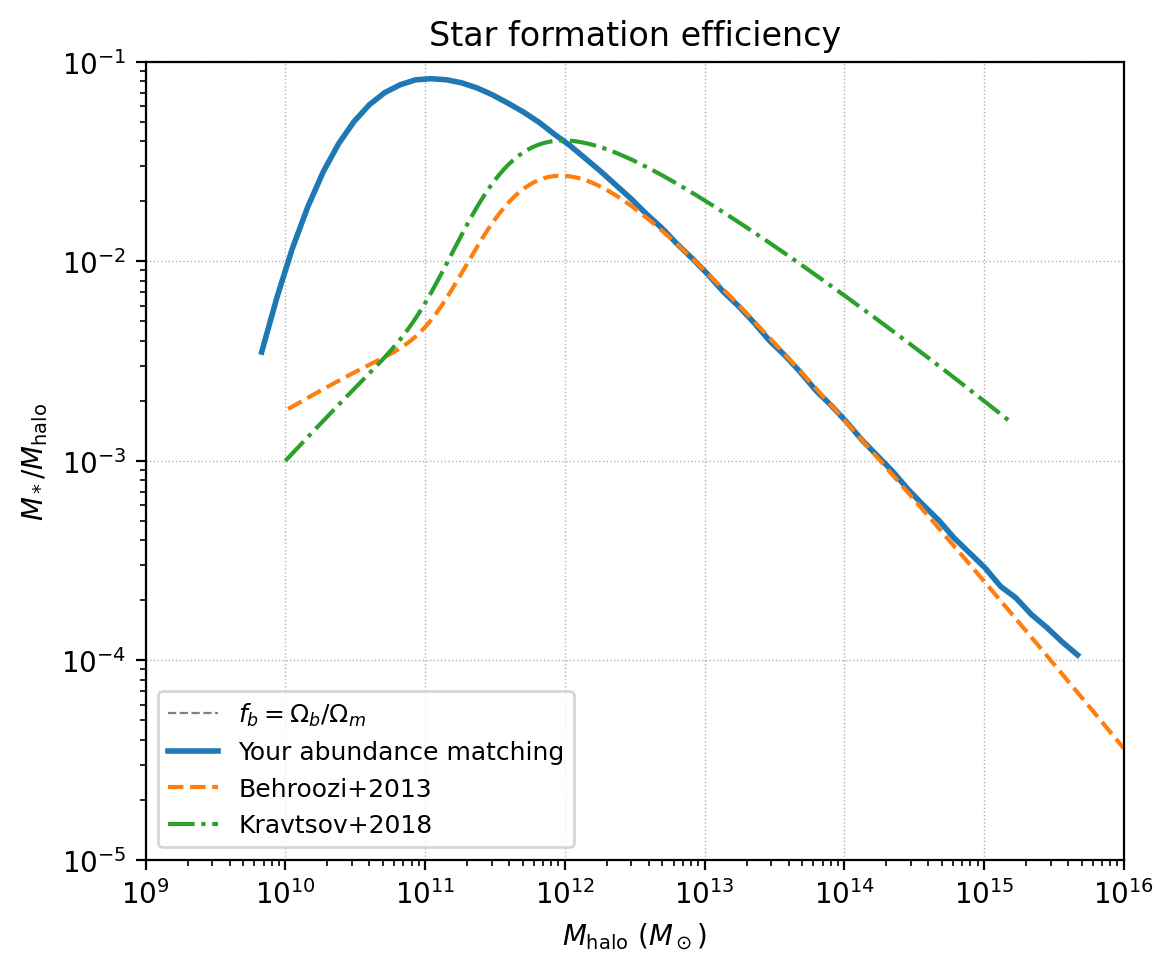

In [6]:
# Exercise 2: Star Formation Efficiency

# Step 1: M_star / M_halo ratio from your abundance matching
# Note: M_star is in Msun (Li & White convention), M_halo is in h^-1 Msun.
# To get the physical ratio, multiply by h.
f_star = M_star_matched[mask] / M_halo_cumul[mask] * cosmo.h

# Step 2: Cosmic baryon fraction
f_baryon = cosmo.Ob0 / cosmo.Om0

# Step 3: Star formation efficiency = (M_*/M_halo) / f_baryon
efficiency = f_star / f_baryon

print('Cosmic baryon fraction f_b = %.4f' % f_baryon)

# Report efficiency at specific halo masses
M_halo_phys = M_halo_cumul[mask] / cosmo.h  # physical Msun
for M_target in [1e11, 1e12, 1e13, 1e14]:
    idx = np.argmin(np.abs(M_halo_phys - M_target))
    print('M_halo = %.0e Msun: M*/M_halo = %.4f, efficiency = %.1f%%'
          % (M_target, f_star[idx], efficiency[idx] * 100))

# Observational constraints
Mvir_beh, ratio_beh = routines.shmrBehroozi13()
Mvir_kra, ratio_kra = routines.shmrKravtsov18()

# Plot
plt.figure(figsize=(6, 5))
plt.loglog()
plt.xlabel(r'$M_{\rm halo}\ (M_\odot)$')
plt.ylabel(r'$M_* / M_{\rm halo}$')
plt.xlim(1e9, 1e16)
plt.ylim(1e-5, 0.1)
plt.grid(lw=0.5, ls=':')

# Baryon fraction line
plt.axhline(f_baryon, ls='--', color='gray', lw=0.8, label=r'$f_b = \Omega_b/\Omega_m$')

# Your result (convert from h-units to physical)
plt.plot(M_halo_cumul[mask] / cosmo.h, f_star, '-', lw=2, label='Your abundance matching')

# Observational constraints
plt.plot(Mvir_beh, ratio_beh, '--', lw=1.5, label='Behroozi+2013')
plt.plot(Mvir_kra, ratio_kra, '-.', lw=1.5, label='Kravtsov+2018')

plt.legend(fontsize=9)
plt.title('Star formation efficiency')
plt.tight_layout()
plt.show()

### SHMR Evolution with Redshift

The stellar-to-halo mass relation evolves with cosmic time. Using the redshift-dependent fitting function from Behroozi et al. (2013), we can track how the peak efficiency mass and the overall normalization shift. At higher redshifts, halos of a given mass have had less time to form stars, so the efficiency is systematically lower.

In [ ]:
# SHMR evolution with redshift (Behroozi+2013)
Mvir_z = 10**np.linspace(10.0, 15.0, 200)
zs_shmr = [0.0, 0.5, 1.0, 2.0, 4.0]
cmap_shmr = plt.get_cmap('viridis')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: M_star vs M_halo
plt.sca(axes[0])
plt.loglog()
plt.xlabel(r'$M_{\rm halo}\ (M_\odot)$')
plt.ylabel(r'$M_*\ (M_\odot)$')
plt.xlim(1e10, 1e15)
plt.grid(lw=0.5, ls=':')

for i, z in enumerate(zs_shmr):
    c = cmap_shmr(float(i) / (len(zs_shmr) - 1.0))
    Mstar_z = routines.mstarBehroozi13(Mvir_z, z)
    plt.plot(Mvir_z, Mstar_z, color=c, lw=1.5, label=r'$z = %.1f$' % z)

plt.legend(fontsize=9)
plt.title('Behroozi+2013: stellar mass evolution')

# Right: efficiency vs M_halo
plt.sca(axes[1])
plt.loglog()
plt.xlabel(r'$M_{\rm halo}\ (M_\odot)$')
plt.ylabel(r'$M_* / M_{\rm halo}$')
plt.xlim(1e10, 1e15)
plt.ylim(1e-5, 0.1)
plt.grid(lw=0.5, ls=':')

f_b = cosmo.Ob0 / cosmo.Om0
plt.axhline(f_b, ls='--', color='gray', lw=0.8, label=r'$f_b = \Omega_b/\Omega_m$')

for i, z in enumerate(zs_shmr):
    c = cmap_shmr(float(i) / (len(zs_shmr) - 1.0))
    Mstar_z = routines.mstarBehroozi13(Mvir_z, z)
    plt.plot(Mvir_z, Mstar_z / Mvir_z, color=c, lw=1.5, label=r'$z = %.1f$' % z)

plt.legend(fontsize=9)
plt.title('Star formation efficiency evolution')

plt.tight_layout()
plt.show()

---

## Galaxy Bias

Galaxies do not perfectly trace the underlying dark matter distribution. They are biased tracers: the galaxy overdensity is related to the matter overdensity by a bias factor $b$:

$$\delta_g(\mathbf{x}) = b \cdot \delta_m(\mathbf{x})$$

This means the galaxy power spectrum is:

$$P_{gg}(k) = b^2 \cdot P_{mm}(k)$$

The bias depends on halo mass:
- Low-mass halos ($M \lesssim 10^{13}\,M_\odot$) are anti-biased ($b < 1$): they live in average environments
- Massive halos ($M \gtrsim 10^{13}\,M_\odot$) are positively biased ($b > 1$): they preferentially form in overdense regions

The peak-background split model predicts:

$$b(\nu) = 1 + \frac{\nu^2 - 1}{\delta_c}$$

where $\nu = \delta_c / \sigma(M)$ is the peak height. More sophisticated models (Tinker+2010) calibrate this against simulations.

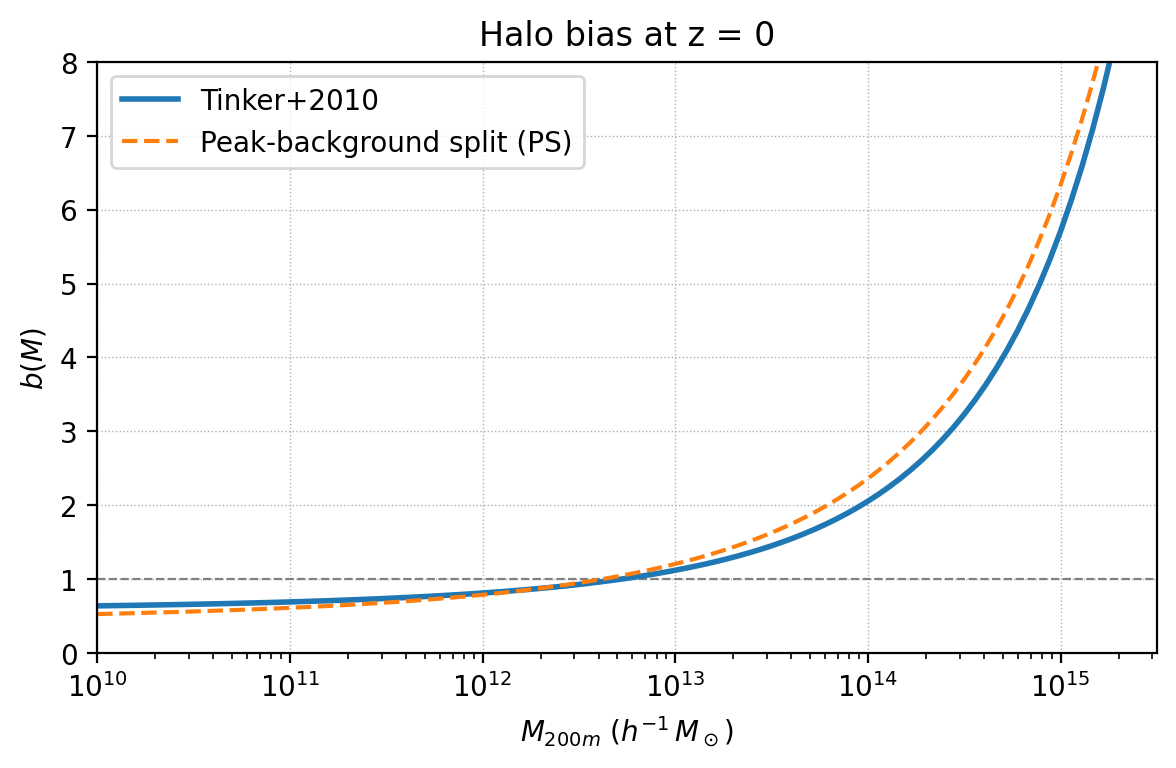

b(M = 1e+11 h^-1 Msun) = 0.69
b(M = 1e+12 h^-1 Msun) = 0.81
b(M = 1e+13 h^-1 Msun) = 1.12
b(M = 1e+14 h^-1 Msun) = 2.05
b(M = 1e+15 h^-1 Msun) = 5.71


In [7]:
# Halo bias as a function of mass
M_bias = 10**np.linspace(10.0, 15.5, 100)

# Tinker+2010 bias (calibrated against simulations)
b_tinker = bias.haloBias(M_bias, model='tinker10', z=0.0, mdef='200m')

# Simple peak-background split (Press-Schechter)
delta_c = 1.686
nu = peaks.peakHeight(M_bias, 0.0)
b_PBS = 1.0 + (nu**2 - 1.0) / delta_c

plt.figure(figsize=(6, 4))
plt.semilogx()
plt.xlabel(r'$M_{200m}\ (h^{-1}\, M_\odot)$')
plt.ylabel(r'$b(M)$')
plt.xlim(M_bias[0], M_bias[-1])
plt.ylim(0, 8)
plt.grid(lw=0.5, ls=':')
plt.axhline(1.0, ls='--', color='gray', lw=0.8)

plt.plot(M_bias, b_tinker, '-', lw=2, label='Tinker+2010')
plt.plot(M_bias, b_PBS, '--', lw=1.5, label='Peak-background split (PS)')

plt.legend()
plt.title('Halo bias at z = 0')
plt.tight_layout()
plt.show()

# Print bias values at key masses
for M_val in [1e11, 1e12, 1e13, 1e14, 1e15]:
    b_val = bias.haloBias(M_val, model='tinker10', z=0.0, mdef='200m')
    print('b(M = %.0e h^-1 Msun) = %.2f' % (M_val, b_val))

### Bias Evolution with Redshift

At higher redshifts, a halo of a given mass is rarer (a more extreme fluctuation), and therefore more biased. This has important implications for galaxy surveys: the same galaxy population traces the matter field more strongly at earlier times.

In [ ]:
# Halo bias evolution with redshift
M_bias_z = 10**np.linspace(10.0, 15.5, 100)
zs_bias = [0.0, 0.5, 1.0, 2.0, 4.0]
cmap_b = plt.get_cmap('viridis')

plt.figure(figsize=(6, 4))
plt.semilogx()
plt.xlabel(r'$M_{200m}\ (h^{-1}\, M_\odot)$')
plt.ylabel(r'$b(M, z)$')
plt.xlim(M_bias_z[0], M_bias_z[-1])
plt.ylim(0, 15)
plt.grid(lw=0.5, ls=':')
plt.axhline(1.0, ls='--', color='gray', lw=0.8)

for i, z in enumerate(zs_bias):
    c = cmap_b(float(i) / (len(zs_bias) - 1.0))
    b_z = bias.haloBias(M_bias_z, model='tinker10', z=z, mdef='200m')
    plt.plot(M_bias_z, b_z, color=c, lw=1.5, label=r'$z = %.1f$' % z)

plt.legend(fontsize=9)
plt.title('Halo bias evolution (Tinker+2010)')
plt.tight_layout()
plt.show()

### Effective Galaxy Bias

In practice, a galaxy sample includes halos of many different masses. The effective bias of the sample is the mass-function-weighted average:

$$b_{\rm eff} = \frac{\int_{M_{\rm min}}^\infty b(M)\, \frac{dn}{d\ln M}\, d\ln M}{\int_{M_{\rm min}}^\infty \frac{dn}{d\ln M}\, d\ln M}$$

For a magnitude-limited sample, $M_{\rm min}$ corresponds to the minimum halo mass that hosts a galaxy bright enough to be observed.

### Exercise 3: Galaxy Bias

In this exercise, you will compute the effective galaxy bias for different halo mass thresholds and predict the galaxy power spectrum.

Steps:
1. FILL IN: Compute the halo bias $b(M)$ using `bias.haloBias()`
2. FILL IN: Compute the effective bias $b_{\rm eff}$ by weighting with the mass function
3. FILL IN: Predict the galaxy power spectrum $P_{gg}(k) = b_{\rm eff}^2 \cdot P_{mm}(k)$
4. Plot $P_{gg}(k)$ for different mass thresholds and compare to $P_{mm}(k)$

M_min = 1e+11: b_eff = 0.76, n_gal = 3.44e-02 h^3/Mpc^3
M_min = 1e+12: b_eff = 0.96, n_gal = 4.47e-03 h^3/Mpc^3
M_min = 1e+13: b_eff = 1.43, n_gal = 5.00e-04 h^3/Mpc^3
M_min = 1e+14: b_eff = 2.66, n_gal = 3.11e-05 h^3/Mpc^3


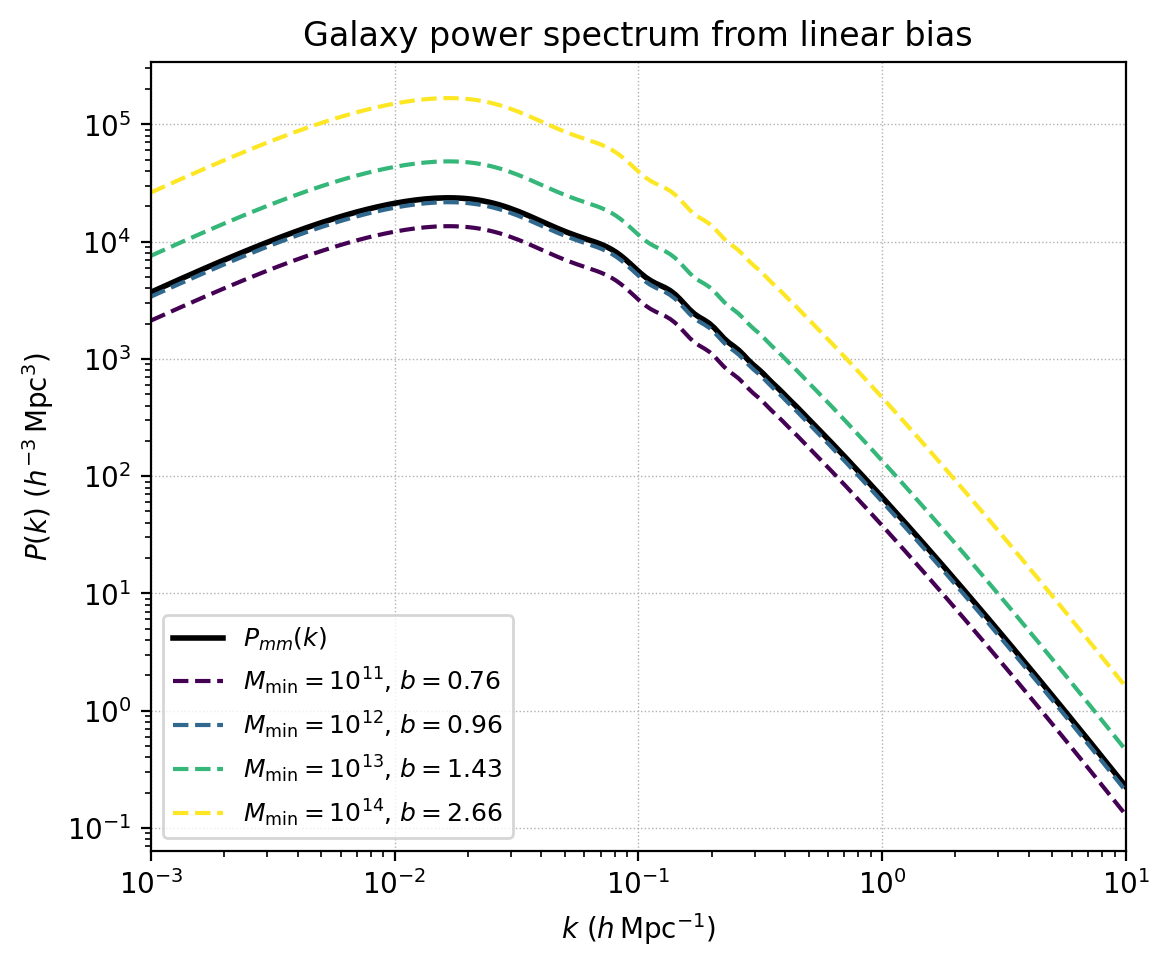

In [8]:
# Exercise 3: Galaxy Bias

# Mass thresholds to consider (minimum halo mass in h^-1 Msun)
M_min_list = [1e11, 1e12, 1e13, 1e14]

# Fine mass grid for integration
M_int = 10**np.linspace(10.0, 16.0, 200)

# Step 1: Compute bias for the integration grid
b_M = bias.haloBias(M_int, model='tinker10', z=0.0, mdef='200m')

# Step 2: Compute mass function for the integration grid
dn_dlnM = mass_function.massFunction(M_int, 0.0, q_in='M', q_out='dndlnM',
                                      model='tinker08', mdef='200m')

# Step 3: Effective bias for each threshold
b_eff_list = []
for M_min in M_min_list:
    mask_int = M_int >= M_min
    # Weighted average: b_eff = integral(b * dn/dlnM dlnM) / integral(dn/dlnM dlnM)
    b_eff = np.trapezoid(b_M[mask_int] * dn_dlnM[mask_int], np.log(M_int[mask_int])) / np.trapezoid(dn_dlnM[mask_int], np.log(M_int[mask_int]))
    b_eff_list.append(b_eff)
    print('M_min = %.0e: b_eff = %.2f, n_gal = %.2e h^3/Mpc^3'
          % (M_min, b_eff, np.trapezoid(dn_dlnM[mask_int], np.log(M_int[mask_int]))))

# Step 4: Galaxy power spectrum
k = 10**np.linspace(-3, 1, 200)
Pk_matter = cosmo.matterPowerSpectrum(k)

plt.figure(figsize=(6, 5))
plt.loglog()
plt.xlabel(r'$k\ (h\, {\rm Mpc}^{-1})$')
plt.ylabel(r'$P(k)\ (h^{-3}\, {\rm Mpc}^3)$')
plt.xlim(k[0], k[-1])
plt.grid(lw=0.5, ls=':')

plt.plot(k, Pk_matter, 'k-', lw=2, label=r'$P_{mm}(k)$')

cmap = plt.get_cmap('viridis')
for i, (M_min, b_eff) in enumerate(zip(M_min_list, b_eff_list)):
    c = cmap(float(i) / (len(M_min_list) - 1.0))
    Pk_gal = b_eff**2 * Pk_matter
    plt.plot(k, Pk_gal, '--', color=c, lw=1.5,
             label=r'$M_{\rm min} = 10^{%d}$, $b = %.2f$' % (int(np.log10(M_min)), b_eff))

plt.legend(fontsize=9)
plt.title('Galaxy power spectrum from linear bias')
plt.tight_layout()
plt.show()

---

# Part 2: Gas Accretion & Cooling

Reference: Cimatti, Fraternali & Nipoti, Ch. 6

With material from Benedikt Diemer (UMD) and Frank van den Bosch (Yale).

## Accretion Shocks and the Virial TemperatureWhen gas accretes onto a dark matter halo, it encounters an accretion shock near the virial radius, heating the gas to approximately the virial temperature:$$T_{\text{vir}} = \frac{\mu m_p}{3 k_B} V_{\text{vir}}^2$$where $\mu \approx 0.59$ is the mean molecular weight for a fully ionized primordial gas, and $V_{\text{vir}}$ is the circular velocity at the virial radius.The virial velocity scales as $V_{\text{vir}} \propto M^{1/3}$, so $T_{\text{vir}} \propto M^{2/3}$.For a Milky Way-mass halo ($M_{\text{vir}} = 10^{12}\,M_\odot$), the virial temperature is about $4 \times 10^5\,$K.

In [3]:
# Virial velocity and temperature for a MW-mass halo
z = 0.0
Mvir = 1E12  # Msun

Mvir_h = Mvir * h
Rvir_h = mass_so.M_to_R(Mvir_h, z, 'vir')
Vvir_MW = np.sqrt(constants.G * Mvir_h / Rvir_h)

print(f'MW halo: V_vir = {Vvir_MW:.1f} km/s')

Tvir_MW = rt.TvirFromMvir(Mvir, z)
print(f'MW halo: T_vir = {Tvir_MW:.2e} K')

# Temperature scaling
print(f'\nT_vir = {rt.mu_ion * constants.M_PROTON / constants.KB / 3 * (100e5)**2:.2e} K * (V_vir/100 km/s)^2')

MW halo: V_vir = 127.7 km/s
MW halo: T_vir = 3.89e+05 K

T_vir = 2.38e+05 K * (V_vir/100 km/s)^2


## Exercise 4: Virial Temperature vs. Halo MassCompute the virial temperature as a function of halo mass from $10^8$ to $10^{15}\,M_\odot$. Identify the mass scales corresponding to:- Atomic hydrogen cooling limit: $T = 10^4\,$K- Milky Way halo: $M = 10^{12}\,M_\odot$- Galaxy cluster: $M = 10^{14.5}\,M_\odot$Also overplot lines marking key temperature thresholds.

Atomic cooling limit (T=10^4 K): M_halo = 4.12e+09 Msun
MW halo (10^12 Msun): T_vir = 3.89e+05 K
Cluster (10^14.5 Msun): T_vir = 1.80e+07 K


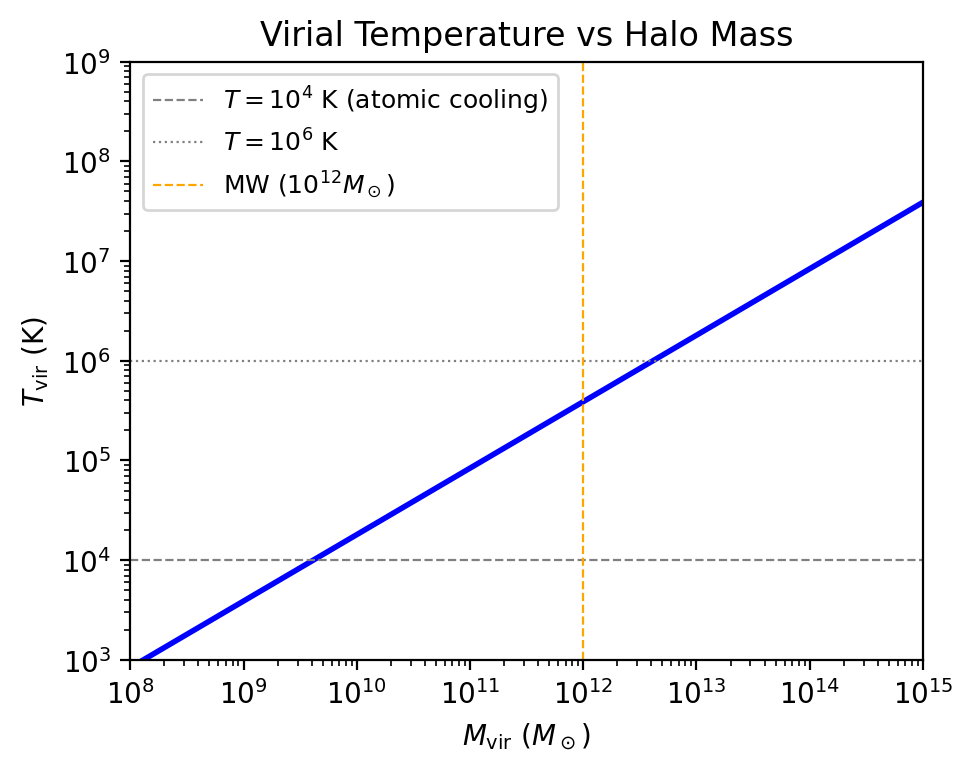

In [4]:
# Exercise 4: Virial temperature vs halo mass
Mvir_arr = 10**np.linspace(8, 15, 200)

Tvir_arr = rt.TvirFromMvir(Mvir_arr, 0.0)

M_atomic = rt.MvirFromTvir(1e4, 0.0)

print(f'Atomic cooling limit (T=10^4 K): M_halo = {M_atomic:.2e} Msun')
print(f'MW halo (10^12 Msun): T_vir = {rt.TvirFromMvir(1e12, 0.0):.2e} K')
print(f'Cluster (10^14.5 Msun): T_vir = {rt.TvirFromMvir(10**14.5, 0.0):.2e} K')

plt.figure(figsize=(5, 4))
plt.loglog(Mvir_arr, Tvir_arr, 'b-', lw=2)
plt.axhline(1e4, ls='--', color='gray', lw=0.8, label=r'$T = 10^4$ K (atomic cooling)')
plt.axhline(1e6, ls=':', color='gray', lw=0.8, label=r'$T = 10^6$ K')
plt.axvline(1e12, ls='--', color='orange', lw=0.8, label=r'MW ($10^{12} M_\odot$)')
plt.xlabel(r'$M_{\rm vir}\ (M_\odot)$')
plt.ylabel(r'$T_{\rm vir}\ (\rm K)$')
plt.xlim(1e8, 1e15)
plt.ylim(1e3, 1e9)
plt.legend(fontsize=9)
plt.title('Virial Temperature vs Halo Mass')
plt.tight_layout()
plt.show()

## Demonstration: Virial Temperature at Multiple Redshifts

The virial temperature depends on redshift because $V_{\rm vir}^2 \propto M / R_{\rm vir}$, and the virial radius depends on the background density $\rho_{\rm vir}(z)$, which increases with redshift.

At fixed halo mass, $T_{\rm vir}$ is **higher** at higher redshift because the halo is more compact ($R_{\rm vir}$ is smaller). This means that massive halos at high $z$ can reach very high temperatures, while the atomic cooling floor ($T = 10^4$ K) corresponds to lower halo masses at high $z$.

In [ ]:
# Virial temperature vs halo mass at multiple redshifts
Mvir_z = 10**np.linspace(8, 15, 200)
zs_tvir = [0.0, 1.0, 2.0, 4.0]
cmap_tvir = plt.get_cmap('viridis')

plt.figure(figsize=(5, 4))
for i, z in enumerate(zs_tvir):
    c = cmap_tvir(float(i) / (len(zs_tvir) - 1))
    Tvir_z = rt.TvirFromMvir(Mvir_z, z)
    plt.loglog(Mvir_z, Tvir_z, color=c, lw=2, label=r'$z = %g$' % z)

plt.axhline(1e4, ls='--', color='gray', lw=0.8, label=r'$T = 10^4$ K (atomic cooling)')
plt.axhline(1e6, ls=':', color='gray', lw=0.8, label=r'$T = 10^6$ K')
plt.xlabel(r'$M_{\rm vir}\ (M_\odot)$')
plt.ylabel(r'$T_{\rm vir}\ (\rm K)$')
plt.xlim(1e8, 1e15)
plt.ylim(1e3, 1e9)
plt.legend(fontsize=9)
plt.title('Virial Temperature: Redshift Evolution')
plt.tight_layout()
plt.show()

## Cooling MechanismsThe post-shock gas must cool in order to condense and form galaxies. The main cooling mechanisms are:1. Bremsstrahlung (free-free): dominant at $T > 10^7\,$K. $\Lambda \propto T^{1/2}$.2. Recombination + line emission: dominant at $10^4 < T < 10^7\,$K. Metal lines (C, N, O, Fe) greatly enhance cooling.3. Compton cooling: scattering off CMB photons, important at high redshift.4. Molecular cooling: H$_2$ and HD at $T < 10^4\,$K (important for first stars).The net cooling rate $\Lambda(T, n, Z)$ depends on temperature, density, and metallicity. We use the tables of Plöckinger & Schaye (2020), which include both cooling and heating (e.g., photoheating from the UV background).The quantity $\Lambda/n^2$ (erg cm$^3$ s$^{-1}$) is approximately density-independent at high $T$.

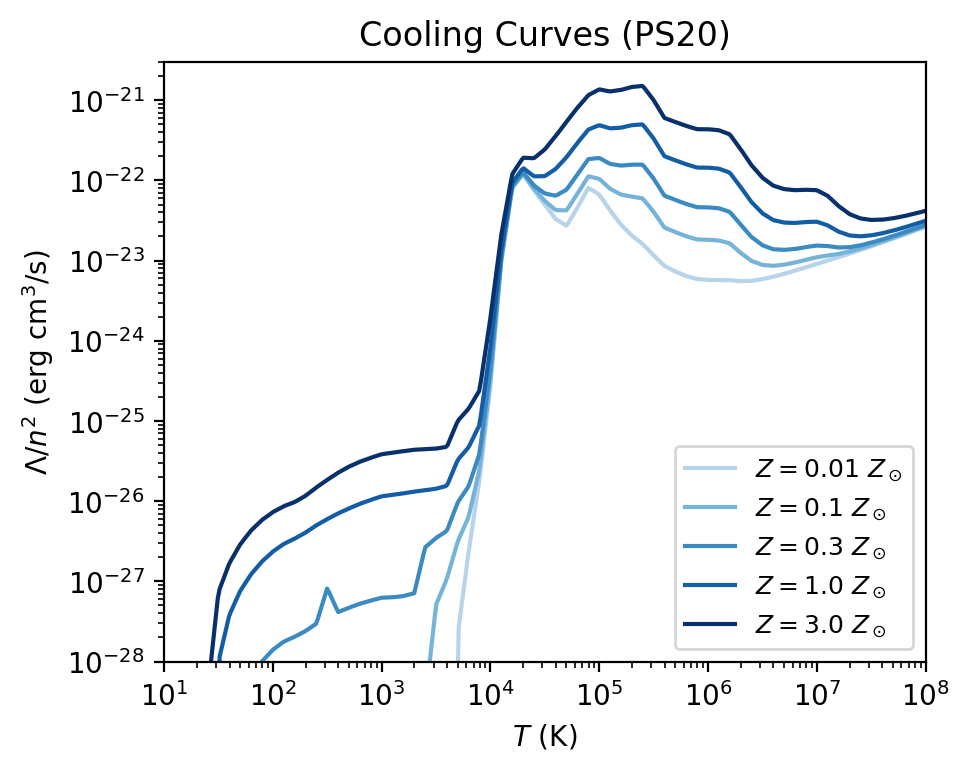

In [5]:
# Cooling curves from Ploeckinger & Schaye (2020) tables
Z_vals = [0.01, 0.1, 0.3, 1.0, 3.0]
cmap_Z = plt.get_cmap('Blues')
cmin, cmax = 0.3, 1.0
n_ref = 1.0  # cm^-3

Tmin, Tmax, _, _, _ = rt.coolingInterpolator(1.0)
T = 10**np.linspace(np.log10(Tmin), np.log10(Tmax), 500)

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$T\ (\rm K)$')
ax.set_ylabel(r'$\Lambda/n^2\ (\rm erg\ cm^3/s)$')
ax.set_xlim(1e1, 1e8)
ax.set_ylim(1e-28, 3e-21)

for i, Z in enumerate(Z_vals):
    Lambda = rt.coolingRate(Z, T, n_ref)
    cval = cmin + (i / (len(Z_vals) - 1)) * (cmax - cmin)
    ax.plot(T, Lambda / n_ref**2, color=cmap_Z(cval),
            label=r'$Z = %s\ Z_\odot$' % str(Z))

ax.legend(loc=4, fontsize=9)
ax.set_title('Cooling Curves (PS20)')
plt.tight_layout()
plt.show()

## Demonstration: Density Dependence of Cooling

The plot above shows $\Lambda/n^2$ at different metallicities but fixed density $n = 1\,\text{cm}^{-3}$. However, the cooling rate is **not** perfectly density-independent: at low temperatures ($T \lesssim 10^4$ K), photoheating from the UV background competes with radiative cooling, and the net rate depends on density.

The figure below shows $\Lambda/n^2$ at different gas densities for fixed solar metallicity. At high $T$, the curves converge (bremsstrahlung and line cooling dominate), but at low $T$ they diverge significantly due to density-dependent photoionization equilibrium (adapted from CFN Chapter 6).

In [ ]:
# Cooling rate at different densities (fixed Z = 1 Zsun)
n_vals = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cmap_n = plt.get_cmap('Reds')
Z_fixed = 1.0  # solar metallicity

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$T\ (\rm K)$')
ax.set_ylabel(r'$\Lambda/n^2\ (\rm erg\ cm^3/s)$')
ax.set_xlim(1e1, 1e8)
ax.set_ylim(1e-28, 3e-21)

for i, n in enumerate(n_vals):
    Lambda_n = rt.coolingRate(Z_fixed, T, n)
    cval = cmin + (i / (len(n_vals) - 1)) * (cmax - cmin)
    ax.plot(T, Lambda_n / n**2, color=cmap_n(cval),
            label=r'$n = %s\,\mathrm{cm}^{-3}$' % str(n))

ax.text(0.05, 0.9, r'$Z = Z_\odot$', transform=ax.transAxes, fontsize=14)
ax.legend(loc=4, fontsize=8)
ax.set_title('Cooling Rate: Density Dependence (PS20)')
plt.tight_layout()
plt.show()

## The Cooling TimeThe cooling time is the time for the gas to radiate away its thermal energy:$$t_{\text{cool}} = \frac{3}{2} \frac{n k_B T}{\Lambda(T,n,Z)}$$where $\Lambda$ is the volumetric cooling rate (erg s$^{-1}$ cm$^{-3}$).Since $\Lambda \propto n^2$, we have $t_{\text{cool}} \propto 1/n$ — denser gas cools faster.The quantity $n \cdot t_{\text{cool}}$ removes the density dependence and shows the intrinsic cooling efficiency at each temperature.

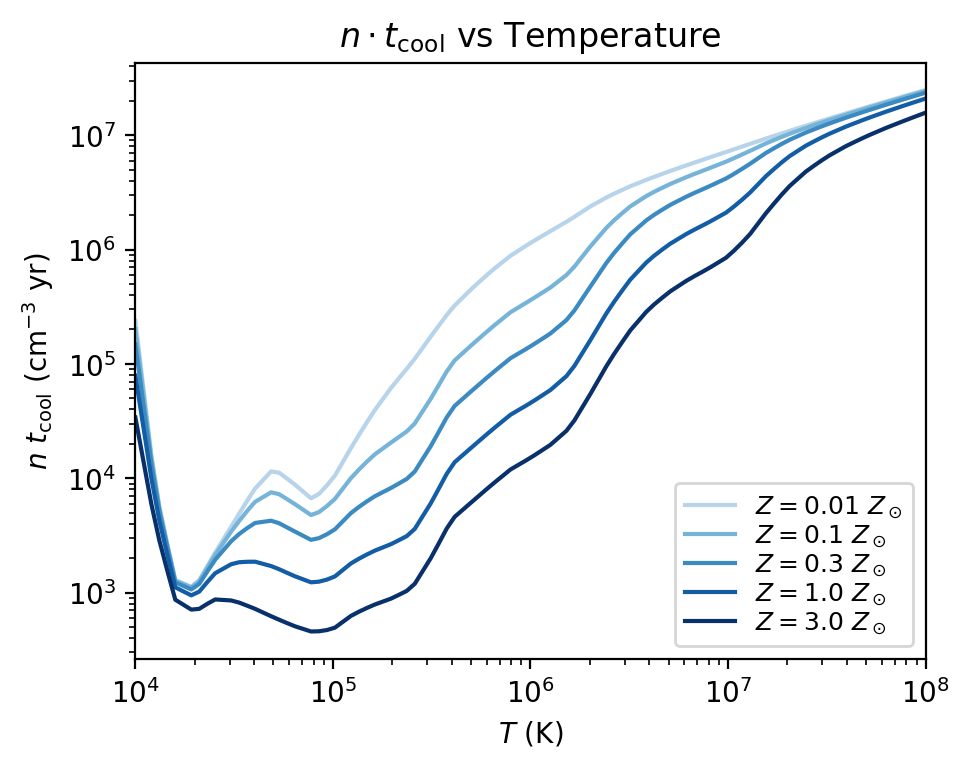

In [6]:
# n * t_cool as a function of temperature
Tmin_plot, Tmax_plot = 1e4, 1e8
T_cool = 10**np.linspace(np.log10(Tmin_plot), np.log10(Tmax_plot), 100)

plt.figure(figsize=(5, 4))
plt.loglog()
plt.xlabel(r'$T\ (\rm K)$')
plt.ylabel(r'$n\ t_{\rm cool}\ (\rm cm^{-3}\ yr)$')
plt.xlim(Tmin_plot, Tmax_plot)

for i, Z in enumerate(Z_vals):
    tcool = rt.n_tcool(Z, T_cool, n_ref) / constants.YEAR
    cval = cmin + (i / (len(Z_vals) - 1)) * (cmax - cmin)
    plt.plot(T_cool, tcool, c=cmap_Z(cval),
             label=r'$Z = %s\ Z_\odot$' % str(Z))

plt.legend(loc=4, fontsize=9, labelspacing=0.1)
plt.title(r'$n \cdot t_{\rm cool}$ vs Temperature')
plt.tight_layout()
plt.show()

## Exercise 5: Cooling Time vs. Free-Fall TimeThe free-fall time is the timescale for gravitational collapse:$$t_{\text{ff}} = \sqrt{\frac{3\pi}{32 G \rho}}$$The ratio $t_{\text{cool}} / t_{\text{ff}}$ determines the cooling regime:- $t_{\text{cool}} < t_{\text{ff}}$: rapid cooling — gas cools faster than it can fall, leading to fragmentation- $t_{\text{cool}} > t_{\text{ff}}$: slow cooling — gas settles into quasi-hydrostatic equilibrium (a hot gaseous halo)Compute $t_{\text{cool}}$ and $t_{\text{ff}}$ at the virial density for halos of mass $10^8$–$10^{15}\,M_\odot$ at several redshifts. Compare to the age of the Universe.

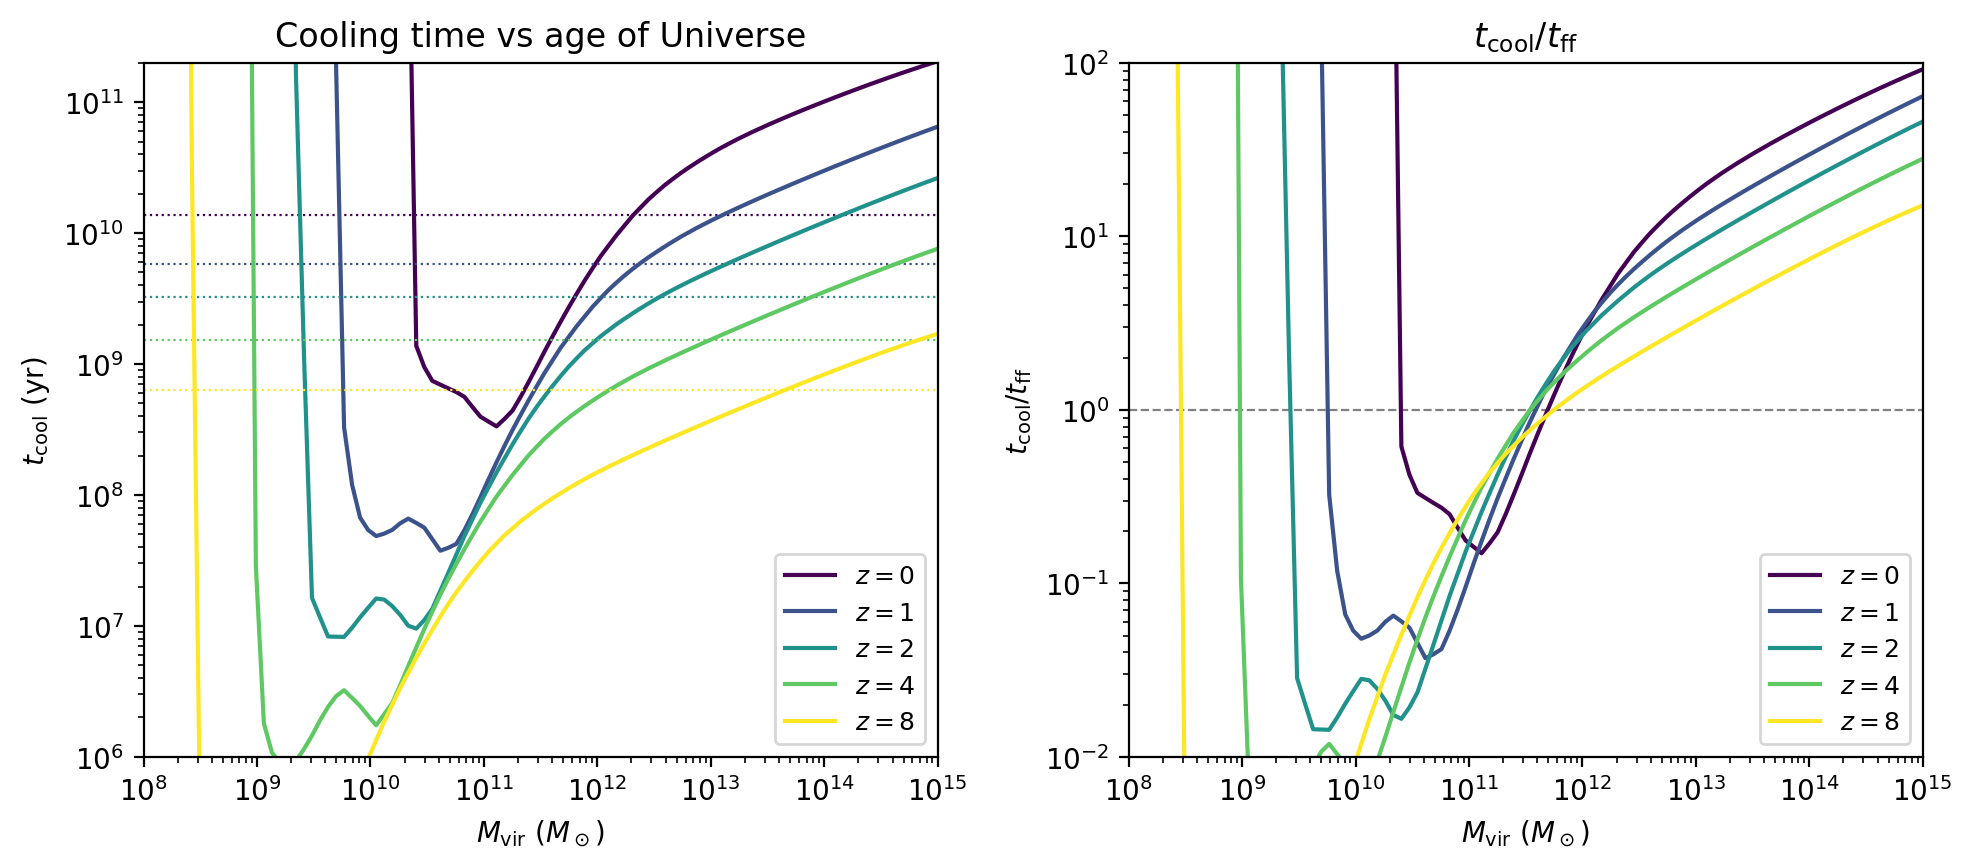

In [7]:
# Exercise 5: Cooling time vs free-fall time
Mvir = 10**np.linspace(8.0, 15.0, 100)
zs = [0, 1, 2, 4, 8]
Z_gas = 0.001  # low metallicity for infalling gas
cmap_z = plt.get_cmap('viridis')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left panel: t_cool vs age of Universe
ax1 = axes[0]
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$M_{\rm vir}\ (M_\odot)$')
ax1.set_ylabel(r'$t_{\rm cool}\ (\rm yr)$')
ax1.set_xlim(Mvir[0], Mvir[-1])
ax1.set_ylim(1e6, 2e11)

for i, z in enumerate(zs):
    c = cmap_z(float(i) / (len(zs) - 1))
    # Age of Universe at this redshift
    tH = cosmo.age(z)
    ax1.axhline(tH * 1e9, ls=':', c=c, lw=0.8)

    tcool = rt.tcoolFromMvir(Mvir, z, Z_gas) / constants.YEAR
    ax1.plot(Mvir, tcool, label=r'$z = %s$' % str(z), c=c)

ax1.legend(fontsize=9)
ax1.set_title(r'Cooling time vs age of Universe')

# Right panel: t_cool / t_ff
ax2 = axes[1]
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$M_{\rm vir}\ (M_\odot)$')
ax2.set_ylabel(r'$t_{\rm cool} / t_{\rm ff}$')
ax2.set_xlim(Mvir[0], Mvir[-1])
ax2.set_ylim(1e-2, 1e2)
ax2.axhline(1.0, ls='--', c='gray', lw=0.8)

for i, z in enumerate(zs):
    c = cmap_z(float(i) / (len(zs) - 1))

    tcool = rt.tcoolFromMvir(Mvir, z, Z_gas)
    tff = rt.tFreeFallVir(z)

    ax2.plot(Mvir, tcool / tff, label=r'$z = %s$' % str(z), c=c)

ax2.legend(fontsize=9)
ax2.set_title(r'$t_{\rm cool} / t_{\rm ff}$')

plt.tight_layout()
plt.show()

## The Cooling Diagram in the $n$-$T$ PlaneWe can visualize the boundary between rapid and slow cooling in the density-temperature plane. The curve $t_{\text{cool}} = t_{\text{ff}}$ separates the two regimes:- Above the curve (high density): $t_{\text{cool}} < t_{\text{ff}}$ — cooling is efficient- Below the curve (low density): $t_{\text{cool}} > t_{\text{ff}}$ — cooling is slowWe also plot lines of constant halo mass. A halo at a given redshift sits at a specific point in this plane (determined by its virial temperature and virial density). As halos grow, they move along these mass tracks.

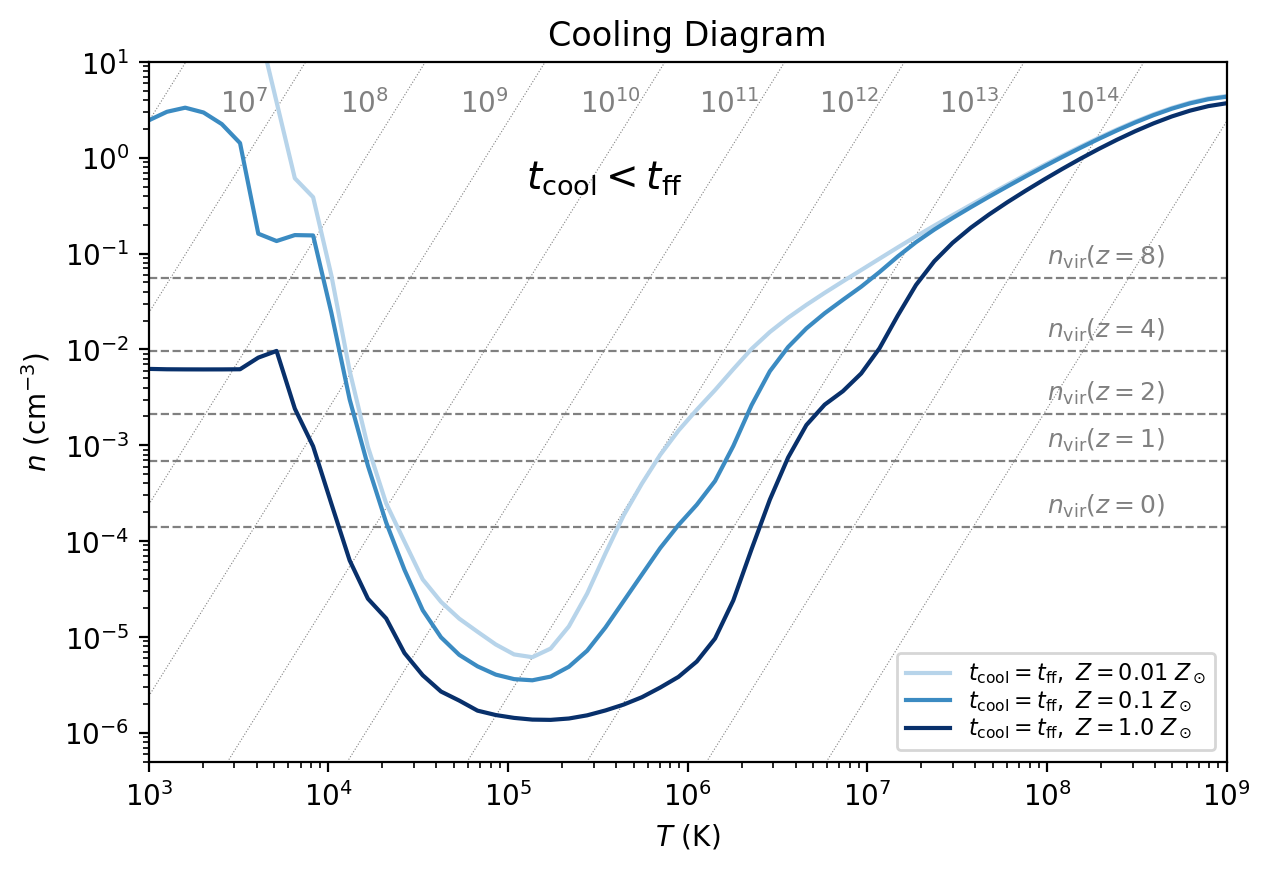

In [8]:
# Phase diagram: n-T plane with t_cool = t_ff boundary
Tmin_plot, Tmax_plot = 1e3, 1e9
Z_vals_phase = [0.01, 0.1, 1.0]
log_M_plot = np.arange(6, 16, 1)
M_plot = 10**log_M_plot
y_max = 1e1

Tmin_tab, Tmax_tab, nmin, nmax, _ = rt.coolingInterpolator(1.0)

def eq(n, Z, T):
    """Equation t_cool - t_ff = 0."""
    tcool = rt.n_tcool(Z, T, n) / n
    n_tot = n / baryon_frac
    rho_tot = n_tot * rt.mu_ion * constants.M_PROTON
    tff = rt.tFreeFall(rho_tot)
    return tcool - tff

T_phase = 10**np.linspace(np.log10(Tmin_plot), np.log10(Tmax_plot), 60)
n_equal = np.zeros_like(T_phase)

plt.figure(figsize=(6.5, 4.5))
plt.loglog()
plt.xlabel(r'$T\ (\rm K)$')
plt.ylabel(r'$n\ (\rm cm^{-3})$')
plt.xlim(Tmin_plot, Tmax_plot)
plt.ylim(5e-7, y_max)
ax = plt.gca()

# Virial density lines at different redshifts
for i, z in enumerate(zs):
    rho_vir = rt.rhoVir(z)
    n_vir = rho_vir / (rt.mu_ion * constants.M_PROTON) * baryon_frac
    ax.axhline(n_vir, ls='--', c='gray', lw=0.8)
    ax.text(Tmax_plot * 0.1, n_vir * 1.4, r'$n_{\rm vir}(z=%s)$' % str(z),
            color='gray', fontsize=9)

# Constant halo mass tracks: n ~ T^3
n0 = rt.rhoVir(0.0) / (rt.mu_ion * constants.M_PROTON) * baryon_frac
for i, M in enumerate(M_plot):
    Tvir0 = rt.TvirFromMvir(M, 0.0)
    n_track = n0 * (T_phase / Tvir0)**3
    ax.plot(T_phase, n_track, ':', c='gray', lw=0.4)
    n_text = y_max * 0.3
    T_text = (n_text / n0)**(1.0 / 3.0) * Tvir0 / 2.0
    if Tmin_plot < T_text < Tmax_plot * 0.5:
        ax.text(T_text, n_text, r'$10^{%d}$' % log_M_plot[i],
                color='gray', fontsize=10)

# t_cool = t_ff curves
for j, Z in enumerate(Z_vals_phase):
    mask = np.ones(len(T_phase), dtype=bool)
    for i in range(len(T_phase)):
        args = (Z, T_phase[i])
        try:
            if eq(nmin * 1.001, *args) * eq(nmax * 0.999, *args) < 0:
                n_equal[i] = scipy.optimize.brentq(eq, nmin * 1.001, nmax * 0.999, args=args)
            else:
                mask[i] = False
        except:
            mask[i] = False
    cval = cmin + (j / (len(Z_vals_phase) - 1)) * (cmax - cmin)
    label = r'$t_{\rm cool}=t_{\rm ff},\ Z=%s\ Z_\odot$' % str(Z)
    ax.plot(T_phase[mask], n_equal[mask], c=cmap_Z(cval), label=label)

ax.text(0.35, 0.82, r'$t_{\rm cool} < t_{\rm ff}$', transform=ax.transAxes, fontsize=14)
ax.legend(frameon=True, fontsize=8, labelspacing=0.1)
plt.title('Cooling Diagram')
plt.tight_layout()
plt.show()

## Reionization and the Baryon FractionAfter reionization ($z \sim 6$–$10$), the UV background heats the intergalactic medium to $\sim 10^4\,$K. This prevents gas from accreting onto small halos whose virial temperature is below this threshold.Gnedin (2000) proposed a fitting function for the suppressed baryon fraction:$$\frac{f_b}{\bar{f}_b} = \left[1 + (2^{\alpha/3} - 1)\left(\frac{M}{M_C}\right)^{-\alpha}\right]^{-3/\alpha}$$where $\alpha = 2$ and $M_C(z)$ is a critical mass from Okamoto et al. (2008):$$M_C(z) = \frac{6 \times 10^9}{h}\, e^{-0.63z}$$Below $M_C$, the baryon fraction is strongly suppressed — these halos cannot accrete gas efficiently.

## Exercise 6: Critical Mass for Galaxy FormationCombine two ideas to determine which halos can form stars:1. Before reionization ($z > z_{\text{reion}}$): the critical mass is set by the atomic hydrogen cooling limit, $T_{\text{vir}} \sim 7000\,$K.2. After reionization ($z < z_{\text{reion}}$): the UV background raises the threshold to $T_{\text{vir}} \sim 20{,}000\,$K.Overplot three idealized halo mass accretion histories (Wechsler+2002):$$M(z) = M_0\, e^{-2 a_{1/2}\, z}$$with $M_0 = 6 \times 10^9\,M_\odot$ and different formation parameters $a_{1/2}$. Determine which halos can form stars.

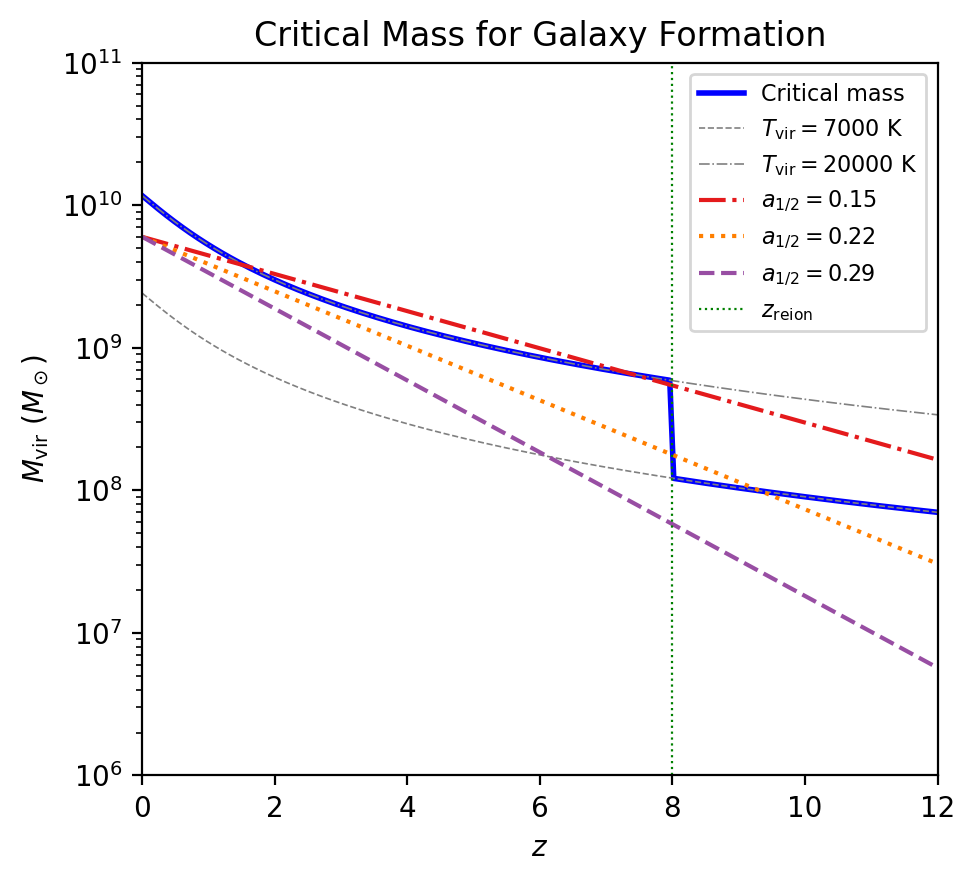

In [9]:
# Exercise 6: Critical mass for galaxy formation
z_arr = np.linspace(0.0, 12.0, 200)
z_reion = 8.0  # reionization redshift
M0 = 6e9  # Msun

plt.figure(figsize=(5, 4.5))
plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$M_{\rm vir}\ (M_\odot)$')
plt.xlim(z_arr[0], z_arr[-1])
plt.ylim(1e6, 1e11)

M_before = rt.MvirFromTvir(7000.0, z_arr)

M_after = rt.MvirFromTvir(20000.0, z_arr)

# Combine: use M_before for z > z_reion, M_after for z <= z_reion
M_crit = np.array(M_after)
mask_pre = (z_arr > z_reion)
M_crit[mask_pre] = M_before[mask_pre]

plt.plot(z_arr, M_crit, 'b-', lw=2, label='Critical mass')
plt.plot(z_arr, M_before, '--', color='gray', lw=0.6,
         label=r'$T_{\rm vir} = 7000$ K')
plt.plot(z_arr, M_after, '-.', color='gray', lw=0.6,
         label=r'$T_{\rm vir} = 20000$ K')

# Plot halo accretion histories
colors_mah = ['#e41a1c', '#ff7f00', '#984ea3']
for i, ac in enumerate([0.15, 0.22, 0.29]):
    Mz = M0 * np.exp(-2.0 * ac * z_arr)
    plt.plot(z_arr, Mz, color=colors_mah[i], lw=1.5,
             ls=['-.', ':', '--'][i],
             label=r'$a_{1/2} = %.2f$' % ac)

plt.axvline(z_reion, ls=':', color='green', lw=0.8, label=r'$z_{\rm reion}$')
plt.legend(fontsize=8, loc='upper right')
plt.title('Critical Mass for Galaxy Formation')
plt.tight_layout()
plt.show()

## Baryon Fraction SuppressionThe plot below shows the suppressed baryon fraction as a function of halo mass at different redshifts. Small halos ($M \ll M_C$) lose most of their baryons after reionization.

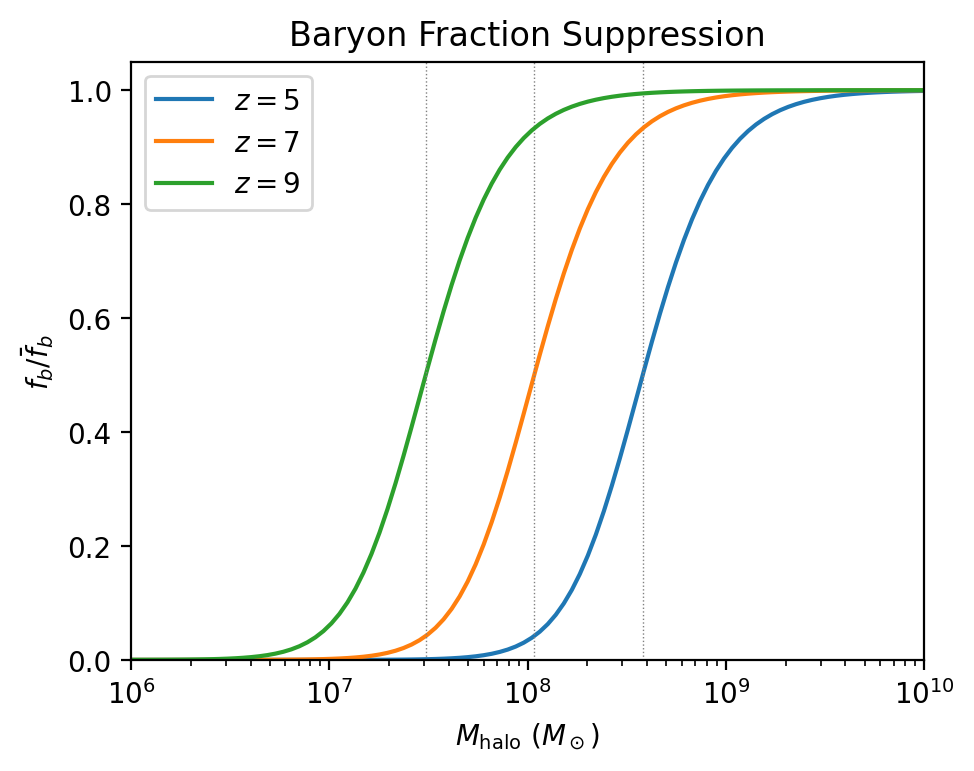

In [10]:
# Baryon fraction suppression (Gnedin 2000 + Okamoto+2008)
alpha_reion = 2.0
M_fb = 10**np.linspace(6.0, 10.0, 100)

plt.figure(figsize=(5, 4))
plt.xscale('log')
plt.xlabel(r'$M_{\rm halo}\ (M_\odot)$')
plt.ylabel(r'$f_b / \bar{f}_b$')
plt.xlim(M_fb[0], M_fb[-1])
plt.ylim(0.0, 1.05)

for z in [5, 7, 9]:
    z_use = min(z, 9.0)
    Mc = 6e9 / h * np.exp(-0.63 * z_use)
    fb_ratio = (1.0 + (2.0**(alpha_reion / 3) - 1) * (M_fb / Mc)**(-alpha_reion))**(-3.0 / alpha_reion)
    plt.plot(M_fb, fb_ratio, label=r'$z = %d$' % z)
    plt.axvline(Mc, ls=':', color='gray', lw=0.5)

plt.legend(fontsize=10)
plt.title('Baryon Fraction Suppression')
plt.tight_layout()
plt.show()

## Demonstration: Combined Critical Mass Diagram

The figure below combines the two key constraints on galaxy formation into a single diagram:

1. **$M_{c1}$ (Reionization)**: Below this mass, halos cannot accrete baryons due to the UV background. Before reionization, the limit is set by atomic cooling ($T_{\rm vir} \sim 7000$ K); after reionization, it jumps to $T_{\rm vir} \sim 20{,}000$ K (Okamoto et al. 2008).

2. **$M_{c2}$ (Cooling)**: Above this mass, the cooling time exceeds the age of the Universe — gas cannot cool and collapse. This sets an upper mass limit for efficient galaxy formation.

The gray shaded region shows the range of halo masses that actually exist at each redshift, defined by the peak height range $0.5 < \nu < 5$. Galaxies can only form in the window between $M_{c1}$ and $M_{c2}$ that overlaps with this region (adapted from CFN Chapter 8).

In [ ]:
# Combined critical mass diagram: M_c1 (reionization) + M_c2 (cooling) + peak height range
from colossus.lss import peaks

z_crit = np.linspace(0.0, 15.0, 200)
Z_crit = 0.01  # low metallicity for infalling gas

# M_c1: reionization threshold
z_reion_crit = 8.0
M_c1_before = rt.MvirFromTvir(7000.0, z_crit)         # atomic cooling before reionization
M_c1_after = 6e9 / h * np.exp(-0.63 * z_crit)         # Okamoto+2008 after reionization
M_c1 = np.where(z_crit > z_reion_crit, M_c1_before, M_c1_after)

# M_c2: cooling threshold (t_cool = t_age of Universe)
M_c2 = np.ones(len(z_crit))
mask_c2 = np.ones(len(z_crit), dtype=bool)
for i in range(len(z_crit)):
    t_age_s = cosmo.age(z_crit[i]) * 1e9 * constants.YEAR
    def eq_c2(logM, _z=z_crit[i], _t=t_age_s):
        return rt.tcoolFromMvir(10**logM, _z, Z_crit) - _t
    try:
        val_lo = eq_c2(11.0)
        val_hi = eq_c2(15.0)
        if val_lo * val_hi < 0:
            logM_sol = scipy.optimize.brentq(eq_c2, 11.0, 15.0)
            M_c2[i] = 10**logM_sol
        else:
            mask_c2[i] = False
    except:
        mask_c2[i] = False

# Peak height range: where halos actually exist (0.5 < nu < 5)
M_nu_5 = peaks.massFromPeakHeight(5.0, z_crit) / h    # h^-1 Msun -> Msun
M_nu_05 = np.ones_like(z_crit) * 1e-10
mask_nu = (z_crit < 12.0)
M_nu_05[mask_nu] = peaks.massFromPeakHeight(0.5, z_crit[mask_nu]) / h

plt.figure(figsize=(5.5, 4.5))
plt.xlabel(r'$z$')
plt.ylabel(r'$M_{\rm halo}\ (M_\odot)$')
plt.yscale('log')
plt.xlim(z_crit[0], z_crit[-1])
plt.ylim(1e5, 1e16)

# Shaded region where halos exist
plt.fill_between(z_crit, M_nu_05, M_nu_5, interpolate=True,
                 color='gray', alpha=0.2, label=r'Halos exist ($0.5 < \nu < 5$)')

# M_c1 (lower limit from reionization)
plt.fill_between(z_crit, M_c1, 1e-5, interpolate=True, color='C0', alpha=0.1)
plt.plot(z_crit, M_c1, color='C0', lw=2, label=r'$M_{\rm c1}$ (Reionization)')

# M_c2 (upper limit from cooling)
plt.fill_between(z_crit[mask_c2], M_c2[mask_c2], 1e20, interpolate=True, color='C1', alpha=0.1)
plt.plot(z_crit[mask_c2], M_c2[mask_c2], color='C1', lw=2, label=r'$M_{\rm c2}$ (Cooling)')

plt.legend(frameon=True, fontsize=9, labelspacing=0.2)
plt.title('Critical Mass for Galaxy Formation')
plt.tight_layout()
plt.show()

---

## Summary

Part 1 -- The Galaxy-Halo Connection:
1. Abundance matching connects galaxies to halos by matching cumulative number densities. The most massive galaxy lives in the most massive halo.
2. The stellar-to-halo mass relation (SHMR) shows that star formation efficiency peaks at $M_{\rm halo} \sim 10^{12}\,M_\odot$ (Milky Way mass), where $\sim 20\%$ of available baryons become stars. Supernova feedback suppresses efficiency in low-mass halos; AGN feedback suppresses it in high-mass halos.
3. Galaxies are biased tracers of the dark matter distribution: $P_{gg}(k) = b^2 P_{mm}(k)$. Massive halos are more biased ($b > 1$). The effective bias of a galaxy sample depends on the halo mass threshold.

Part 2 -- Gas Accretion & Cooling:
4. Gas shock-heats to $T_{\rm vir} \propto M^{2/3}$ when accreting onto halos. MW-mass halos have $T_{\rm vir} \sim 4 \times 10^5\,$K.
5. The net cooling rate depends on $T$, $n$, and $Z$. Metal-line cooling dominates at $10^4$--$10^7\,$K; bremsstrahlung dominates above $10^7\,$K.
6. When $t_{\rm cool} < t_{\rm ff}$, gas cools rapidly and fragments. When $t_{\rm cool} > t_{\rm ff}$, a hot gaseous halo forms. Massive clusters have $t_{\rm cool} > t_{\rm age}$, so their gas never fully cools.
7. Reionization suppresses gas accretion onto halos with $T_{\rm vir} < 2 \times 10^4\,$K ($M \lesssim 10^{9.5}\,M_\odot$), setting a minimum halo mass for galaxy formation.